Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Outputs will be saved to: /content/drive/MyDrive/german_contract_results/

📂 Scanning dataset path: /content/drive/MyDrive/german_contract_dataset/v3_2026-01/
✅ Found main data file: /content/drive/MyDrive/german_contract_dataset/v3_2026-01/data/clauses.json
📊 Loaded 886 clauses from clauses.json

📋 DataFrame shape: (886, 6)
📋 Columns: ['content', 'heading', 'topic', 'true_label', 'true_explanation', 'true_hurt-rules']

🔍 First 5 rows of the dataset:
                                             content  \
0      Das Arbeitsverhältnis beginnt zum 01.12.2021.   
1  Ist der Arbeitnehmer infolge unverschuldeter K...   
2  Der Arbeitnehmer verpflichtet sich, während de...   
3  Nach Ablauf der Probezeit beträgt die Kündigun...   
4  Die Vertragsparteien müssen Ansprüche aus dem ...   

                               heading                             topic  \
0

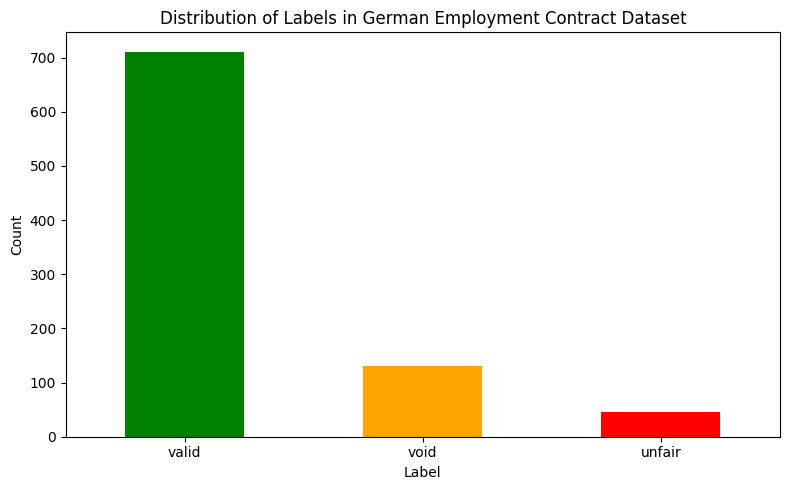


🔍 Sample of the data (first 5 rows with text and label):

--- Sample 1 ---
Text: Das Arbeitsverhältnis beginnt zum 01.12.2021.
Label: valid

--- Sample 2 ---
Text: Ist der Arbeitnehmer infolge unverschuldeter Krankheit arbeitsunfähig, so besteht Anspruch auf Fortzahlung der Arbeitsvergütung bis zur Dauer von sechs Wochen nach den gesetzlichen Bestimmungen. Die A...
Label: valid

--- Sample 3 ---
Text: Der Arbeitnehmer verpflichtet sich, während der Dauer des Arbeitsverhältnisses und auch nach Ausscheiden, über alle Betriebs- und Geschäftsgeheimnisse Stillschweigen zu bewahren. Dies betrifft insbeso...
Label: unfair

--- Sample 4 ---
Text: Nach Ablauf der Probezeit beträgt die Kündigungsfrist vier Wochen zum 15 oder Ende eines Kalendermonats. Jede gesetzliche Verlängerung der Kündigungsfrist zugunsten des Arbeitnehmers gilt in gleicher ...
Label: valid

--- Sample 5 ---
Text: Die Vertragsparteien müssen Ansprüche aus dem Arbeitsverhältnis innerhalb von drei, Monaten (oder: sechs Monate

In [5]:
# ============================================
# PROBASHI SHIELD - COMPLETE CODE (CORRECTED)
# German Employment Contract Dataset (V3)
# For Google Colab T4 GPU
# ============================================

# ========== STEP 1: MOUNT GOOGLE DRIVE & SETUP ==========
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Set output path
OUTPUT_PATH = "/content/drive/MyDrive/german_contract_results/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"✅ Outputs will be saved to: {OUTPUT_PATH}")

# ========== STEP 2: LOAD DATASET FROM JSON FILES ==========
DATASET_PATH = "/content/drive/MyDrive/german_contract_dataset/v3_2026-01/"

print(f"\n📂 Scanning dataset path: {DATASET_PATH}")

# Find the main data file - clauses.json (this contains the actual contract clauses)
clauses_file = os.path.join(DATASET_PATH, "data", "clauses.json")

if os.path.exists(clauses_file):
    print(f"✅ Found main data file: {clauses_file}")
    with open(clauses_file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # Convert to DataFrame
    df = pd.DataFrame(data)
    print(f"📊 Loaded {len(df)} clauses from clauses.json")
else:
    print(f"❌ clauses.json not found at {clauses_file}")
    # Try alternative path
    alt_paths = glob.glob(os.path.join(DATASET_PATH, "**/clauses.json"), recursive=True)
    if alt_paths:
        print(f"✅ Found at: {alt_paths[0]}")
        with open(alt_paths[0], 'r', encoding='utf-8') as f:
            data = json.load(f)
        df = pd.DataFrame(data)
        print(f"📊 Loaded {len(df)} clauses")

print(f"\n📋 DataFrame shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")

# Display first few rows
print("\n🔍 First 5 rows of the dataset:")
print(df.head())

# Identify the correct columns for text and label
# From your data, it looks like:
# - 'content' contains the actual clause text
# - 'true_label' contains the label (valid/unfair/void)
# - 'heading' contains the clause heading/section

text_col = None
label_col = None

for col in df.columns:
    col_lower = col.lower()
    # Look for text content columns
    if col in ['content', 'text', 'clause', 'sentence']:
        text_col = col
    # Look for label columns
    if col in ['true_label', 'label', 'class', 'category']:
        label_col = col

# If still not found, try other options
if text_col is None and 'content' in df.columns:
    text_col = 'content'
if text_col is None and len(df.columns) >= 1:
    text_col = df.columns[0]
    print(f"⚠️ Assuming first column '{text_col}' as text column")

if label_col is None and 'true_label' in df.columns:
    label_col = 'true_label'
if label_col is None and len(df.columns) >= 2:
    label_col = df.columns[1]
    print(f"⚠️ Assuming second column '{label_col}' as label column")

# Rename for consistency
if text_col:
    df = df.rename(columns={text_col: 'text'})
if label_col:
    df = df.rename(columns={label_col: 'label'})

print(f"\n✅ Using text column: 'text' (original: '{text_col}')")
print(f"✅ Using label column: 'label' (original: '{label_col}')")

# Remove any rows with missing text or label
df = df.dropna(subset=['text'])
if 'label' in df.columns:
    df = df.dropna(subset=['label'])

print(f"\n📊 Final dataset shape after cleaning: {df.shape}")

# Show unique labels
if 'label' in df.columns:
    print(f"\n🏷️ Unique labels in dataset: {df['label'].unique()}")

    # Label distribution
    print("\n📊 Label distribution:")
    label_counts = df['label'].value_counts()
    print(label_counts)

    # Plot label distribution
    plt.figure(figsize=(8, 5))
    label_counts.plot(kind='bar', color=['green', 'orange', 'red'])
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.title('Distribution of Labels in German Employment Contract Dataset')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'label_distribution.png'), dpi=300)
    plt.show()
else:
    print("⚠️ No 'label' column found in the dataset!")
    print("Available columns:", df.columns.tolist())

# Show sample data
print("\n🔍 Sample of the data (first 5 rows with text and label):")
if 'text' in df.columns and 'label' in df.columns:
    sample_df = df[['text', 'label']].head(10)
    for idx, row in sample_df.iterrows():
        print(f"\n--- Sample {idx+1} ---")
        print(f"Text: {row['text'][:200]}..." if len(row['text']) > 200 else f"Text: {row['text']}")
        print(f"Label: {row['label']}")

In [6]:
# ========== STEP 3: DATA PREPROCESSING & LABEL ENCODING ==========
print("\n" + "="*50)
print("STEP 3: DATA PREPROCESSING")
print("="*50)

from sklearn.preprocessing import LabelEncoder
import re

# Basic text cleaning function
def clean_text(text):
    """Clean text by removing special characters and extra spaces"""
    text = str(text)
    text = text.lower()
    # Keep German characters (ä, ö, ü, ß) and English letters
    text = re.sub(r'[^a-zäöüß\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning to text column
df['cleaned_text'] = df['text'].apply(clean_text)

print(f"✅ Text cleaning completed")

# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Display label mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"\n🏷️ Label mapping: {label_mapping}")
print(f"   (valid={label_mapping['valid']}, unfair={label_mapping['unfair']}, void={label_mapping['void']})")

# Display class distribution
print(f"\n📊 Class distribution after encoding:")
print(df['label_encoded'].value_counts())



STEP 3: DATA PREPROCESSING
✅ Text cleaning completed

🏷️ Label mapping: {'unfair': np.int64(0), 'valid': np.int64(1), 'void': np.int64(2)}
   (valid=1, unfair=0, void=2)

📊 Class distribution after encoding:
label_encoded
1    711
2    130
0     45
Name: count, dtype: int64


In [8]:
# ========== STEP 4: TRAIN/TEST/VALIDATION SPLIT ==========
print("\n" + "="*50)
print("STEP 4: TRAIN/TEST/VALIDATION SPLIT")
print("="*50)

from sklearn.model_selection import train_test_split

X = df['cleaned_text'].values
y = df['label_encoded'].values

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: 15% validation, 15% test (from 30% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n📊 Split sizes:")
print(f"   Training set: {len(X_train)} samples")
print(f"   Validation set: {len(X_val)} samples")
print(f"   Test set: {len(X_test)} samples")

# Check class distribution in each split
def print_split_dist(y, name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"   {name}:")
    for u, c in zip(unique, counts):
        label_name = le.classes_[u]
        print(f"      {label_name}: {c} ({c/len(y)*100:.1f}%)")

print(f"\n📊 Class distribution in splits:")
print_split_dist(y_train, "Training")
print_split_dist(y_val, "Validation")
print_split_dist(y_test, "Test")


STEP 4: TRAIN/TEST/VALIDATION SPLIT

📊 Split sizes:
   Training set: 620 samples
   Validation set: 133 samples
   Test set: 133 samples

📊 Class distribution in splits:
   Training:
      unfair: 31 (5.0%)
      valid: 498 (80.3%)
      void: 91 (14.7%)
   Validation:
      unfair: 7 (5.3%)
      valid: 106 (79.7%)
      void: 20 (15.0%)
   Test:
      unfair: 7 (5.3%)
      valid: 107 (80.5%)
      void: 19 (14.3%)


In [9]:
# ========== STEP 5: TF-IDF FEATURE EXTRACTION ==========
print("\n" + "="*50)
print("STEP 5: TF-IDF FEATURE EXTRACTION")
print("="*50)

from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"✅ TF-IDF completed")
print(f"   Feature matrix shape: {X_train_tfidf.shape}")
print(f"   Number of features: {len(tfidf.get_feature_names_out())}")


STEP 5: TF-IDF FEATURE EXTRACTION
✅ TF-IDF completed
   Feature matrix shape: (620, 5000)
   Number of features: 5000


In [10]:
# ========== STEP 6: TRADITIONAL ML MODELS ==========
print("\n" + "="*50)
print("STEP 6: TRAINING TRADITIONAL ML MODELS")
print("="*50)

results = {}

# 6.1 Dummy Classifier (Baseline)
from sklearn.dummy import DummyClassifier
print("\n--- 6.1 Dummy Classifier (Baseline) ---")
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_tfidf, y_train)
y_pred_dummy = dummy.predict(X_test_tfidf)
results['Dummy (Baseline)'] = {
    'accuracy': accuracy_score(y_test, y_pred_dummy),
    'precision': precision_score(y_test, y_pred_dummy, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_dummy, average='weighted'),
    'f1': f1_score(y_test, y_pred_dummy, average='weighted')
}
print(f"   Accuracy: {results['Dummy (Baseline)']['accuracy']:.4f}")
print(f"   F1-Score: {results['Dummy (Baseline)']['f1']:.4f}")

# 6.2 Logistic Regression
print("\n--- 6.2 Logistic Regression ---")
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr, average='weighted'),
    'recall': recall_score(y_test, y_pred_lr, average='weighted'),
    'f1': f1_score(y_test, y_pred_lr, average='weighted')
}
print(f"   Accuracy: {results['Logistic Regression']['accuracy']:.4f}")
print(f"   F1-Score: {results['Logistic Regression']['f1']:.4f}")

# 6.3 Random Forest
print("\n--- 6.3 Random Forest ---")
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'recall': recall_score(y_test, y_pred_rf, average='weighted'),
    'f1': f1_score(y_test, y_pred_rf, average='weighted')
}
print(f"   Accuracy: {results['Random Forest']['accuracy']:.4f}")
print(f"   F1-Score: {results['Random Forest']['f1']:.4f}")

# 6.4 XGBoost
print("\n--- 6.4 XGBoost ---")
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', use_label_encoder=False)
xgb.fit(X_train_tfidf, y_train)
y_pred_xgb = xgb.predict(X_test_tfidf)
results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb, average='weighted'),
    'recall': recall_score(y_test, y_pred_xgb, average='weighted'),
    'f1': f1_score(y_test, y_pred_xgb, average='weighted')
}
print(f"   Accuracy: {results['XGBoost']['accuracy']:.4f}")
print(f"   F1-Score: {results['XGBoost']['f1']:.4f}")


STEP 6: TRAINING TRADITIONAL ML MODELS

--- 6.1 Dummy Classifier (Baseline) ---
   Accuracy: 0.8045
   F1-Score: 0.7174

--- 6.2 Logistic Regression ---
   Accuracy: 0.8195
   F1-Score: 0.8081

--- 6.3 Random Forest ---
   Accuracy: 0.8195
   F1-Score: 0.7617

--- 6.4 XGBoost ---
   Accuracy: 0.8195
   F1-Score: 0.7717



STEP 7: TRAINING DEEP LEARNING MODELS
✅ Using device: cpu

--- 7.1 Bi-LSTM ---
   Input shape: (620, 100)
   Model built successfully
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 720ms/step - accuracy: 0.7694 - loss: 0.8111 - val_accuracy: 0.7970 - val_loss: 0.6546
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 561ms/step - accuracy: 0.8032 - loss: 0.6486 - val_accuracy: 0.7970 - val_loss: 0.6349
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 661ms/step - accuracy: 0.8032 - loss: 0.6093 - val_accuracy: 0.7970 - val_loss: 0.6171
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 546ms/step - accuracy: 0.8065 - loss: 0.5326 - val_accuracy: 0.7970 - val_loss: 0.5869
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 629ms/step - accuracy: 0.8516 - loss: 0.3925 - val_accuracy: 0.8120 - val_loss: 0.6250
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 503ms/step - accuracy: 0.9097 - loss: 0.2521 - val_accuracy: 0.7820 - val_loss: 0.7909
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 637ms/step - accuracy: 0.9226 - loss: 0.1864 - va

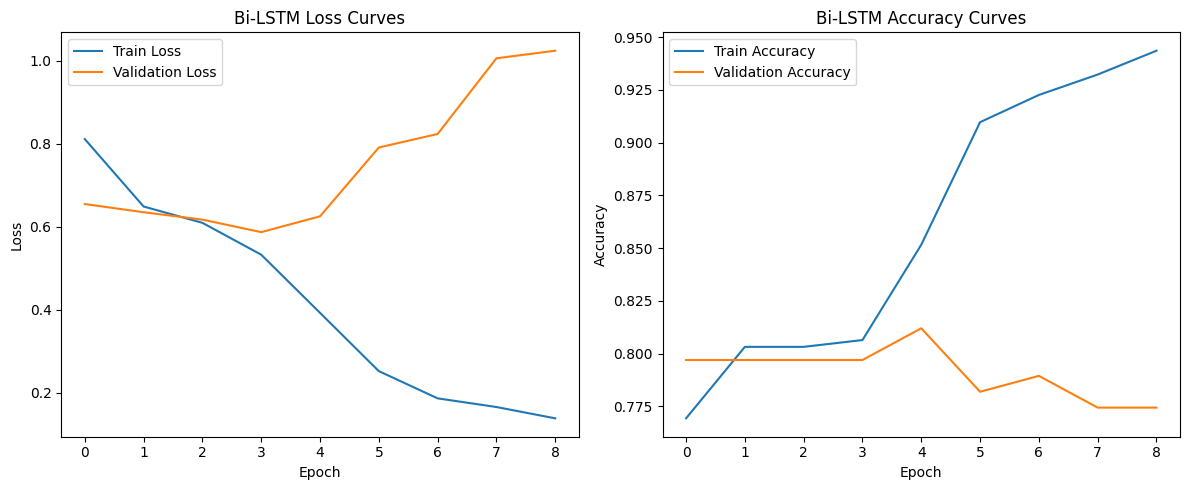

In [11]:
# ========== STEP 7: DEEP LEARNING MODELS ==========
print("\n" + "="*50)
print("STEP 7: TRAINING DEEP LEARNING MODELS")
print("="*50)

# Check for GPU
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

# 7.1 Bi-LSTM Model
print("\n--- 7.1 Bi-LSTM ---")

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Parameters
MAX_WORDS = 10000
MAX_LEN = 100
EMBEDDING_DIM = 100

# Tokenize
tokenizer_keras = Tokenizer(num_words=MAX_WORDS)
tokenizer_keras.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_val), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_test), maxlen=MAX_LEN)

print(f"   Input shape: {X_train_seq.shape}")

# Build Bi-LSTM model
bilstm_model = Sequential()
bilstm_model.add(Embedding(MAX_WORDS, EMBEDDING_DIM, input_length=MAX_LEN))
bilstm_model.add(Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3)))
bilstm_model.add(Dropout(0.5))
bilstm_model.add(Dense(64, activation='relu'))
bilstm_model.add(Dropout(0.3))
bilstm_model.add(Dense(len(le.classes_), activation='softmax'))

bilstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"   Model built successfully")

# Train with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = bilstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
y_pred_bilstm_proba = bilstm_model.predict(X_test_seq)
y_pred_bilstm = np.argmax(y_pred_bilstm_proba, axis=1)

results['Bi-LSTM'] = {
    'accuracy': accuracy_score(y_test, y_pred_bilstm),
    'precision': precision_score(y_test, y_pred_bilstm, average='weighted'),
    'recall': recall_score(y_test, y_pred_bilstm, average='weighted'),
    'f1': f1_score(y_test, y_pred_bilstm, average='weighted')
}
print(f"   Accuracy: {results['Bi-LSTM']['accuracy']:.4f}")
print(f"   F1-Score: {results['Bi-LSTM']['f1']:.4f}")

# Plot Bi-LSTM loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Bi-LSTM Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Bi-LSTM Accuracy Curves')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'bilstm_training_curves.png'), dpi=300)
plt.show()



STEP 8: GENERATING RESULTS

📊 Model Performance Comparison:
                     accuracy  precision  recall      f1
Dummy (Baseline)       0.8045     0.6472  0.8045  0.7174
Logistic Regression    0.8195     0.8001  0.8195  0.8081
Random Forest          0.8195     0.8039  0.8195  0.7617
XGBoost                0.8195     0.8080  0.8195  0.7717
Bi-LSTM                0.8120     0.7950  0.8120  0.7346
✅ Saved to: /content/drive/MyDrive/german_contract_results/model_comparison.csv


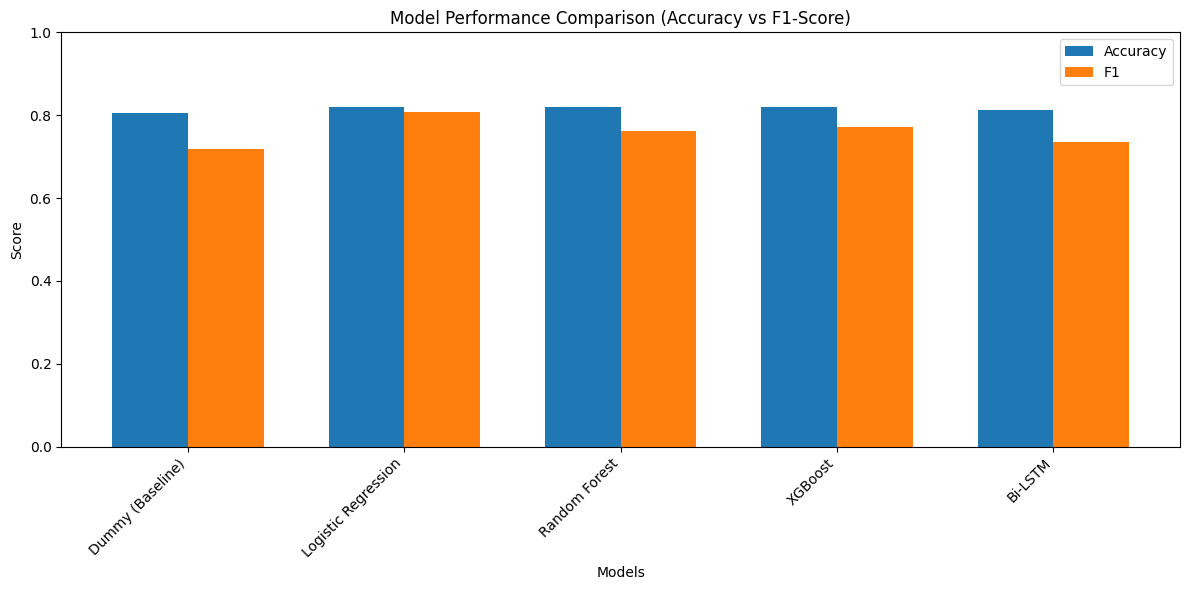


🏆 Best model: Logistic Regression


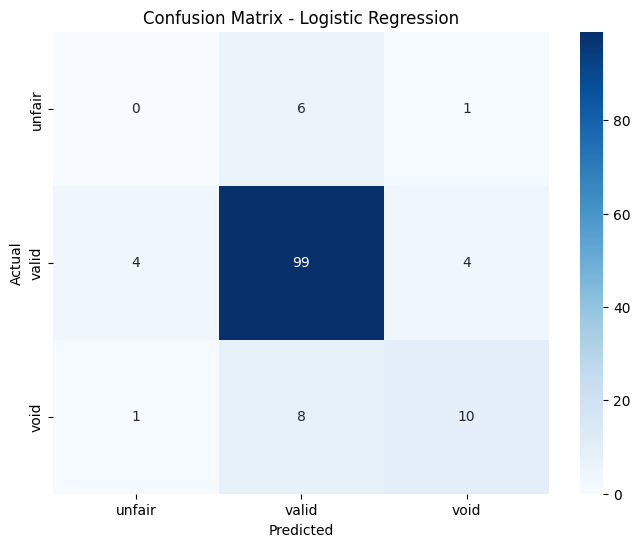

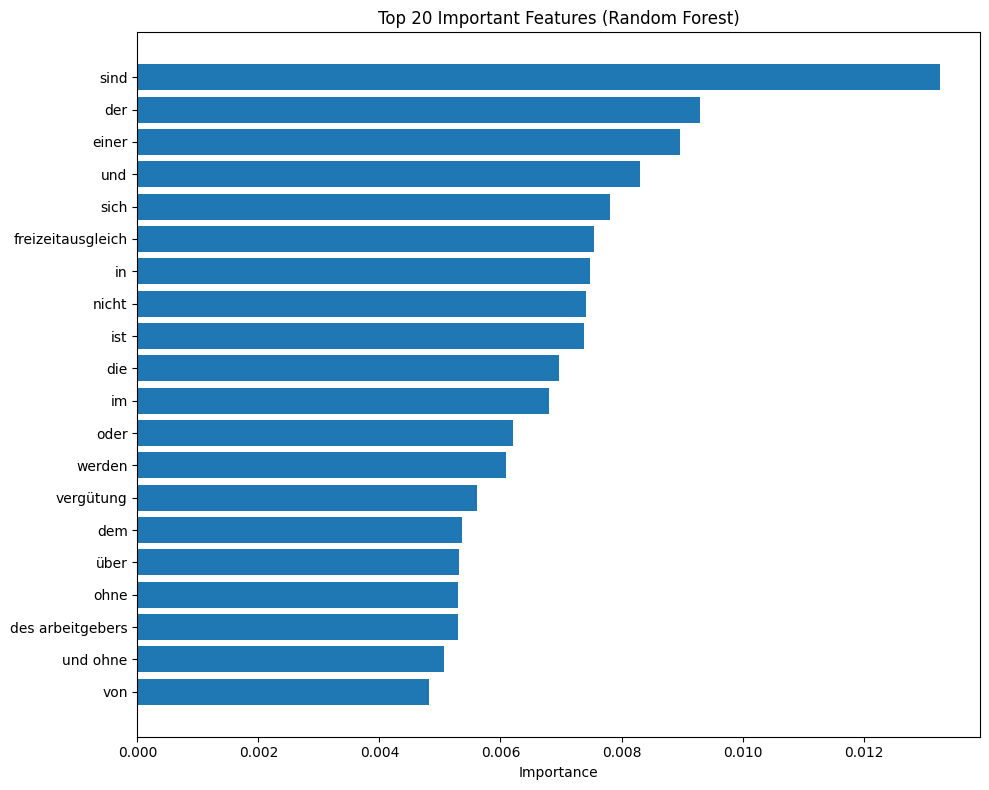


📋 Classification Report for Best Model:
              precision    recall  f1-score   support

      unfair       0.00      0.00      0.00         7
       valid       0.88      0.93      0.90       107
        void       0.67      0.53      0.59        19

    accuracy                           0.82       133
   macro avg       0.51      0.48      0.50       133
weighted avg       0.80      0.82      0.81       133



In [12]:
# ========== STEP 8: GENERATE RESULTS TABLE AND CHARTS ==========
print("\n" + "="*50)
print("STEP 8: GENERATING RESULTS")
print("="*50)

# Create results DataFrame
results_df = pd.DataFrame(results).T
print("\n📊 Model Performance Comparison:")
print(results_df.round(4))

# Save to CSV
results_df.to_csv(os.path.join(OUTPUT_PATH, 'model_comparison.csv'))
print(f"✅ Saved to: {OUTPUT_PATH}model_comparison.csv")

# Chart 1: Model Comparison Bar Chart
plt.figure(figsize=(12, 6))
metrics = ['accuracy', 'f1']
x = np.arange(len(results_df))
width = 0.35

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    plt.bar(x + i*width, values, width, label=metric.capitalize())

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison (Accuracy vs F1-Score)')
plt.xticks(x + width/2, results_df.index, rotation=45, ha='right')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'model_comparison.png'), dpi=300)
plt.show()

# Chart 2: Confusion Matrix for Best Model
best_model = results_df['f1'].idxmax()
print(f"\n🏆 Best model: {best_model}")

# Get predictions for best model
if best_model == 'Logistic Regression':
    best_preds = y_pred_lr
elif best_model == 'Random Forest':
    best_preds = y_pred_rf
elif best_model == 'XGBoost':
    best_preds = y_pred_xgb
else:
    best_preds = y_pred_bilstm

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model}')
plt.savefig(os.path.join(OUTPUT_PATH, 'confusion_matrix.png'), dpi=300)
plt.show()

# Chart 3: Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    'feature': tfidf.get_feature_names_out(),
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][::-1], feature_importance['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 20 Important Features (Random Forest)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'feature_importance.png'), dpi=300)
plt.show()

# Chart 4: Classification Report
print("\n📋 Classification Report for Best Model:")
print(classification_report(y_test, best_preds, target_names=le.classes_))

# Save classification report
with open(os.path.join(OUTPUT_PATH, 'classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test, best_preds, target_names=le.classes_))

In [13]:
# ========== STEP 9: CROSS-VALIDATION (Robustness Check) ==========
print("\n" + "="*50)
print("STEP 9: CROSS-VALIDATION")
print("="*50)

from sklearn.model_selection import cross_val_score, StratifiedKFold

# Perform 5-fold cross-validation on Random Forest
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
                            X_train_tfidf, y_train, cv=cv, scoring='f1_weighted')

print(f"Random Forest 5-fold CV F1-Scores: {cv_scores}")
print(f"Mean CV F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Save CV results
with open(os.path.join(OUTPUT_PATH, 'cv_results.txt'), 'w') as f:
    f.write(f"Random Forest 5-fold Cross-Validation Results:\n")
    f.write(f"Individual F1-Scores: {cv_scores}\n")
    f.write(f"Mean: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}\n")

print("\n" + "="*50)
print("✅ ALL STEPS COMPLETED SUCCESSFULLY!")
print(f"📁 All outputs saved to: {OUTPUT_PATH}")
print("="*50)

# List all generated files
print("\n📄 Generated files:")
for file in os.listdir(OUTPUT_PATH):
    print(f"   - {file}")


STEP 9: CROSS-VALIDATION
Random Forest 5-fold CV F1-Scores: [0.79226139 0.81244451 0.81045261 0.81244451 0.85304975]
Mean CV F1-Score: 0.8161 (+/- 0.0200)

✅ ALL STEPS COMPLETED SUCCESSFULLY!
📁 All outputs saved to: /content/drive/MyDrive/german_contract_results/

📄 Generated files:
   - label_distribution.png
   - bilstm_training_curves.png
   - model_comparison.csv
   - model_comparison.png
   - confusion_matrix.png
   - feature_importance.png
   - classification_report.txt
   - cv_results.txt
